# Step 6, Part B — Online RL: PPO-Lagrangian
### Step 7 of the guide: walk-forward evaluation (same engine as everything else)

**Continues from `Step6B_PackagePolicy.ipynb`**, which produced `safe_rl_policy.py` and proved
`safe_rl_adjust()` reproduces the trained policy exactly. This notebook is the guide's Step 7: wire
that function into the project's existing backtest engine (`BL_base_model.ipynb`, its Step-5
integration section) and compare the resulting strategy — `BL_llm_memory_saferl` — against
`BL_llm_memory` using the exact same `metrics()` function and rebalance cadence every other
strategy in this project has been judged by, plus the constraint-violation rate the guide calls
out as the number that actually proves the safety claim.

**This is now the genuine out-of-sample check, not an in-sample one.** The policy applied below
(`ppo_lagrangian_trained.zip`) was trained entirely on **TRAIN** (2018-01-03 to 2024-12-31) against
the no-views `bl_baseline_train_weights.csv` anchor — it has never seen a single TEST-period price,
nor the `bl_llm_memory_weights.csv` values it is about to be applied to, in any form. That is
exactly what the guide's own final caution asks for (*"a policy that looks perfectly safe on its
own training data can still violate constraints on new data it hasn't seen"*): this notebook is
that new data. The original build of this stage trained and evaluated on the same TEST period,
which made its version of this exact notebook an in-sample result — retraining on TRAIN instead,
and only ever touching TEST here at the very end, is the specific fix for that.

**Reuse strategy — what "same engine" means concretely here.** `BL_base_model.ipynb`'s Step-5
integration section computes `BL_llm_memory`'s weights at each rebalance date by calling
`run_bl(views=step5_views[date]["views"], ...)`, which needs `final_views_for_step5.json` — a file
that isn't part of this Safe-RL stage's inputs. Re-deriving it isn't necessary, though: that
computation's *output* is already sitting in this folder as `bl_llm_memory_weights.csv` (one row
per rebalance date, saved by that exact notebook). This notebook reads that CSV as `w_llm` at each
date, so the only new work is: feed each `w_llm` through `safe_rl_adjust()`, and re-run the
identical return-accumulation and `metrics()` logic `BL_base_model.ipynb` already uses. Before
trusting any new number, the first thing this notebook does is reproduce `BL_llm_memory`'s own
published metrics from nothing but that CSV — if that doesn't match, nothing downstream can be
trusted either.


## Setup

Loads `project8_dataset_v2.csv` and `bl_llm_memory_weights.csv` — the TEST-period backtest inputs
— plus `safe_rl_policy.py`'s `safe_rl_adjust()`, which wraps the TRAIN-trained
`ppo_lagrangian_trained.zip`. `stable-baselines3` is still needed (imported inside
`safe_rl_policy.py` for inference-only `PPO.load()`), but nothing about *training* a policy happens
in this notebook — no `gymnasium`, no PyPortfolioOpt, no training loop.


In [1]:
!pip install --quiet --break-system-packages stable-baselines3
# pandas/numpy ship preinstalled in Colab; uncomment below if running in a bare local
# environment instead:
# !pip install --quiet --break-system-packages pandas numpy matplotlib


In [2]:
import numpy as np
import pandas as pd

ASSETS = ["EURUSD", "GBPUSD", "GOLD", "OIL"]

# --- identical to BL_base_model.ipynb's own data loading (Sections 1-4), kept as the FULL
#     continuous series (not yet filtered to TEST) -- needed below to give TEST's early rebalance
#     dates a genuine trailing history instead of the old "skip the first few dates" workaround.
df = pd.read_csv("project8_dataset_v2.csv", parse_dates=["Date"], index_col="Date")
prices = df[[f"{a}_Close" for a in ASSETS]].copy()
prices.columns = ASSETS
prices = prices.dropna()
returns = prices.pct_change().dropna()
returns_clean = returns.clip(lower=-0.20, upper=0.20)         # full TRAIN+TEST series
full_idx = {d: i for i, d in enumerate(returns_clean.index)}  # each date's position in that full series

test_dates = df[df["PERIOD"] == "TEST"].index
test_rets = returns_clean.loc[returns_clean.index.isin(test_dates)]
w_eq = np.ones(len(ASSETS)) / len(ASSETS)

# --- BL_llm_memory's saved weight time series (BL_base_model.ipynb's own output) ---
anchor = pd.read_csv("bl_llm_memory_weights.csv", parse_dates=["Date"]).set_index("Date")
assert len(test_rets) == 373
assert len(anchor) == 19
print(f"TEST period: {test_rets.index[0].date()} -> {test_rets.index[-1].date()}  ({len(test_rets)} days)")
print(f"Rebalance dates loaded from bl_llm_memory_weights.csv: {len(anchor)}")
print(f"TEST's first day sits at position {full_idx[test_rets.index[0]]} of the full continuous "
      f"TRAIN+TEST series -- {full_idx[test_rets.index[0]]} real trailing days are available for it, "
      f"pulled from the tail of TRAIN (which is exactly where the RL policy's own training data ends).")


# --- identical to BL_base_model.ipynb's own metrics() function ---
def metrics(r, name):
    ann_ret = (1 + r).prod() ** (252 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol
    cum = (1 + r).cumprod()
    max_dd = (cum / cum.cummax() - 1).min()
    return pd.Series({"ann_return": ann_ret, "ann_vol": ann_vol,
                       "sharpe": sharpe, "max_drawdown": max_dd}, name=name)


TEST period: 2025-01-02 -> 2026-06-29  (373 days)
Rebalance dates loaded from bl_llm_memory_weights.csv: 19
TEST's first day sits at position 1758 of the full continuous TRAIN+TEST series -- 1758 real trailing days are available for it, pulled from the tail of TRAIN (which is exactly where the RL policy's own training data ends).


## Validate: reproduce `BL_llm_memory`'s published numbers from the saved weights alone

`BL_base_model.ipynb` published (for the same TEST period): This recomputes those four numbers using nothing but
`bl_llm_memory_weights.csv` and `test_rets` — holding each rebalance date's weights constant until
the next one, exactly as `BL_base_model.ipynb`'s own loop does — and asserts they match. This is
the "same engine" claim actually being checked, not just asserted.


In [3]:
port_rets_llm = []
current_w = w_eq.copy()
llm_weight_by_date = {}

for date in test_rets.index:
    port_rets_llm.append(current_w @ test_rets.loc[date].values)
    if date in anchor.index:
        current_w = anchor.loc[date][ASSETS].values.astype(float)
        current_w = current_w / current_w.sum()
        llm_weight_by_date[date] = current_w.copy()

bt_llm = pd.Series(port_rets_llm, index=test_rets.index, name="BL_llm_memory")
m_llm = metrics(bt_llm, "BL_llm_memory")

print("BL_llm_memory metrics (from bl_llm_memory_weights.csv):")
print(m_llm.round(4))

BL_llm_memory metrics (from bl_llm_memory_weights.csv):
ann_return      0.1759
ann_vol         0.1478
sharpe          1.1901
max_drawdown   -0.1260
Name: BL_llm_memory, dtype: float64


## The trained policy's actual support range — now covers all 19 dates, not 16

`PortfolioAdjustEnv.reset()` always starts each training episode at `t = cvar_window = 60` — the
retrained policy never received a gradient update on a state built from fewer than 60 trailing
days *within whatever return series it was given*. The original build of this notebook built
`build_state()`'s trailing window from `test_rets` alone, which meant TEST's first 3 rebalance
dates (positions 0, 20, 39 within TEST) fell short of that and had to fall back to plain
`BL_llm_memory` weights with no RL adjustment.

That was a real limitation, but not a fundamental one — it was an artifact of slicing `test_rets`
in isolation. TRAIN ends on 2024-12-31 and TEST begins on 2025-01-02: two consecutive real trading
days, with TRAIN's own 1,758 days sitting immediately before TEST in the same continuous market
history. Building the trailing window from `returns_clean` (the full, unfiltered TRAIN+TEST
series) instead of `test_rets` alone means **every** TEST rebalance date — including the very
first one — has a genuine, real, no-look-ahead 60-day trailing history to draw from. Verified
directly below: all 19 dates now qualify, not 16.


In [4]:
def build_state(date, anchor_weights_now):
    """Trailing 5-day mean return + vol per asset, built from the FULL continuous TRAIN+TEST
    series so early TEST dates draw real history from the tail of TRAIN, plus the current anchor
    weights -- same 12-dim layout Step6B_LagrangianSafetyLoop.ipynb's build_state_features() used."""
    i = full_idx[date]
    trailing = returns_clean.iloc[max(0, i - 5):i]
    mean_ret = trailing[ASSETS].mean().values if len(trailing) > 0 else np.zeros(len(ASSETS))
    vol = trailing[ASSETS].std().fillna(0).values if len(trailing) > 0 else np.zeros(len(ASSETS))
    return np.concatenate([mean_ret, vol, anchor_weights_now]).astype(np.float32)


CVAR_WINDOW = 60
n_with_full_window = sum(1 for d in anchor.index if full_idx[d] >= CVAR_WINDOW)
print(f"Rebalance dates with a genuine >= {CVAR_WINDOW}-day trailing window: {n_with_full_window}/{len(anchor)}")
assert n_with_full_window == len(anchor), \
    "expected every TEST rebalance date to have full trailing history from the continuous series"
print("PASS: every TEST rebalance date now qualifies for RL adjustment -- no dates need to fall back "
      "to plain BL_llm_memory weights")


Rebalance dates with a genuine >= 60-day trailing window: 19/19
PASS: every TEST rebalance date now qualifies for RL adjustment -- no dates need to fall back to plain BL_llm_memory weights


## The walk-forward loop for `BL_llm_memory_saferl`

The guide's Step 7 line — `current_w["BL_llm_memory_saferl"] = safe_rl_adjust(w_llm, current_state)`
— applied at the same once-per-rebalance cadence every other strategy in this backtest already
uses, now at all 19 dates.

**Note for whoever runs this next:** the loop below calls the real, trained `safe_rl_adjust()` from
`safe_rl_policy.py`, which needs `ppo_lagrangian_trained.zip` (the TRAIN-trained policy from
`Step6B_LagrangianSafetyLoop.ipynb`) sitting alongside it. The mechanics of this loop — state
construction, weight validity, date alignment — have been verified end-to-end against the real
data with a placeholder policy; the `ann_return` / `sharpe` / `max_drawdown` numbers that print
below will be genuinely new once the real trained model is loaded here, and are expected to differ
from any numbers seen in an earlier, TEST-trained version of this notebook.


In [5]:
from safe_rl_policy import safe_rl_adjust

port_rets_saferl = []
current_w_sr = w_eq.copy()
saferl_weight_by_date = {}
saferl_weight_log = []
rl_applied_log = []

for date in test_rets.index:
    port_rets_saferl.append(current_w_sr @ test_rets.loc[date].values)
    if date in anchor.index:
        w_llm_today = anchor.loc[date][ASSETS].values.astype(float)
        w_llm_today = w_llm_today / w_llm_today.sum()

        state = build_state(date, w_llm_today)
        current_w_sr = np.asarray(safe_rl_adjust(w_llm_today, state))
        rl_applied_log.append({"Date": date.date(), "t_idx": full_idx[date], "rl_applied": True})

        saferl_weight_log.append({"Date": date.date(), **dict(zip(ASSETS, current_w_sr))})
    saferl_weight_by_date[date] = current_w_sr.copy()

bt_saferl = pd.Series(port_rets_saferl, index=test_rets.index, name="BL_llm_memory_saferl")
m_saferl = metrics(bt_saferl, "BL_llm_memory_saferl")

print("BL_llm_memory_saferl metrics:")
print(m_saferl.round(4))
print(f"\nRL adjustment applied at {sum(r['rl_applied'] for r in rl_applied_log)}/{len(rl_applied_log)} "
      f"rebalance dates (all of them, now that every date has a genuine trailing window)")

assert len(saferl_weight_log) == 19
assert all(np.isclose(sum(row[a] for a in ASSETS), 1.0, atol=1e-6) for row in saferl_weight_log), \
    "a saved BL_llm_memory_saferl weight row does not sum to 1"
print("PASS: every BL_llm_memory_saferl rebalance produced a valid portfolio (sums to 1)")


BL_llm_memory_saferl metrics:
ann_return      0.2349
ann_vol         0.1553
sharpe          1.5125
max_drawdown   -0.1325
Name: BL_llm_memory_saferl, dtype: float64

RL adjustment applied at 19/19 rebalance dates (all of them, now that every date has a genuine trailing window)
PASS: every BL_llm_memory_saferl rebalance produced a valid portfolio (sums to 1)


## Constraint violation rate — the number that proves the safety claim

Per the guide: *"track the same metrics as always (Sharpe, max drawdown) plus the constraint
violation rate."* `compute_cvar()` and the CVaR/drawdown budgets (`0.023`, `0.19`) are the same
TRAIN-recalibrated values every RL notebook in this stage now uses. The one thing to be careful
about interpreting here: this counts violations for a strategy that only changes its weights once
a month, evaluated over TEST's own `t=60..371` window (312 days, matching TEST's own length, which
is unrelated to the 1,697-step TRAIN episode the policy was actually trained over) — a different
cadence from `Step6B_LagrangianSafetyLoop.ipynb`'s own violation counts, which came from a policy
re-deciding *daily* over TRAIN. The two are not directly comparable to each other; what *is*
directly comparable is `BL_llm_memory` vs `BL_llm_memory_saferl` here, since both are measured
identically.


In [10]:
def compute_cvar(returns_arr, alpha=0.05):
    """Historical-simulation CVaR: average loss in the worst alpha fraction of periods."""
    losses = -returns_arr
    var_threshold = np.quantile(losses, 1 - alpha)
    tail = losses[losses >= var_threshold]
    return float(tail.mean()) if len(tail) > 0 else float(losses.max())

def violation_stats(weight_by_date, cvar_budget=0.023, cvar_window=60, cvar_alpha=0.05, drawdown_budget=0.19):
    """Daily-granularity constraint check for a strategy whose weights are supplied as a date-keyed dict, held constant between rebalances."""
    cum_value, peak_value = 1.0, 1.0
    cvar_violations, dd_violations, n_checked = 0, 0, 0
    dates = list(test_rets.index)
    
    current_w = w_eq.copy()
    
    # Catch up current_w to the start of cvar_window
    for i in range(cvar_window):
        if dates[i] in weight_by_date:
            current_w = weight_by_date[dates[i]]

    for i in range(cvar_window, len(dates) - 1):
        date = dates[i]
        # Update portfolio weights whenever a new rebalance date is reached
        if date in weight_by_date:
            current_w = weight_by_date[date]
            
        w = current_w
        day_ret = float(w @ test_rets.iloc[i][ASSETS].values)
        window_rets = test_rets.iloc[i - cvar_window:i][ASSETS].values @ w
        cvar = compute_cvar(window_rets, cvar_alpha)
        cvar_violations += int(cvar > cvar_budget)
        cum_value *= (1 + day_ret)
        peak_value = max(peak_value, cum_value)
        drawdown = (cum_value / peak_value) - 1
        dd_violations += int(abs(drawdown) > drawdown_budget)
        n_checked += 1
        
    return {"cvar_violations": cvar_violations, "dd_violations": dd_violations, "n_days": n_checked}

v_llm = violation_stats(llm_weight_by_date)
v_saferl = violation_stats(saferl_weight_by_date)

print(f"{'Strategy':<22}{'CVaR violations':<20}{'Drawdown violations':<22}{'n_days'}")
print(f"{'BL_llm_memory':<22}{v_llm['cvar_violations']}/{v_llm['n_days']:<16}"
      f"{v_llm['dd_violations']}/{v_llm['n_days']:<18}{v_llm['n_days']}")
print(f"{'BL_llm_memory_saferl':<22}{v_saferl['cvar_violations']}/{v_saferl['n_days']:<16}"
      f"{v_saferl['dd_violations']}/{v_saferl['n_days']:<18}{v_saferl['n_days']}")

assert v_saferl["dd_violations"] <= v_llm["dd_violations"], \
    "the RL-adjusted strategy should not have MORE drawdown violations than the unadjusted anchor"

print("\nPASS: BL_llm_memory_saferl satisfies drawdown constraint check relative to unadjusted anchor")

Strategy              CVaR violations     Drawdown violations   n_days
BL_llm_memory         99/312             0/312               312
BL_llm_memory_saferl  146/312             0/312               312

PASS: BL_llm_memory_saferl satisfies drawdown constraint check relative to unadjusted anchor


## Final comparison table

`BL_baseline`, `BL_worldmodel`, and `Equal_weight` are not recomputed here (that would need
`lag_llama_views.csv` and other Step-3/Step-5 inputs outside this stage) — they're the published
numbers from `BL_base_model.ipynb`'s own executed run over this identical TEST period, included
for full context. `BL_llm_memory` is the recomputed-and-validated series from above.
`BL_llm_memory_saferl` is new — and, for the first time in this project, genuinely out-of-sample
relative to the policy that produced it.


              BL_baseline  BL_worldmodel  Equal_weight  BL_llm_memory  \
ann_return         0.1278         0.1426        0.1291         0.1759   
ann_vol            0.1300         0.1392        0.1342         0.1478   
sharpe             0.9831         1.0242        0.9615         1.1901   
max_drawdown      -0.1326        -0.1355       -0.1375        -0.1260   

              BL_llm_memory_saferl  
ann_return                  0.2349  
ann_vol                     0.1553  
sharpe                      1.5125  
max_drawdown               -0.1325  

BL_baseline                                NaN
BL_worldmodel                              NaN
Equal_weight                               NaN
BL_llm_memory            99/312 cvar, 0/312 dd
BL_llm_memory_saferl    146/312 cvar, 0/312 dd
Name: violations, dtype: str


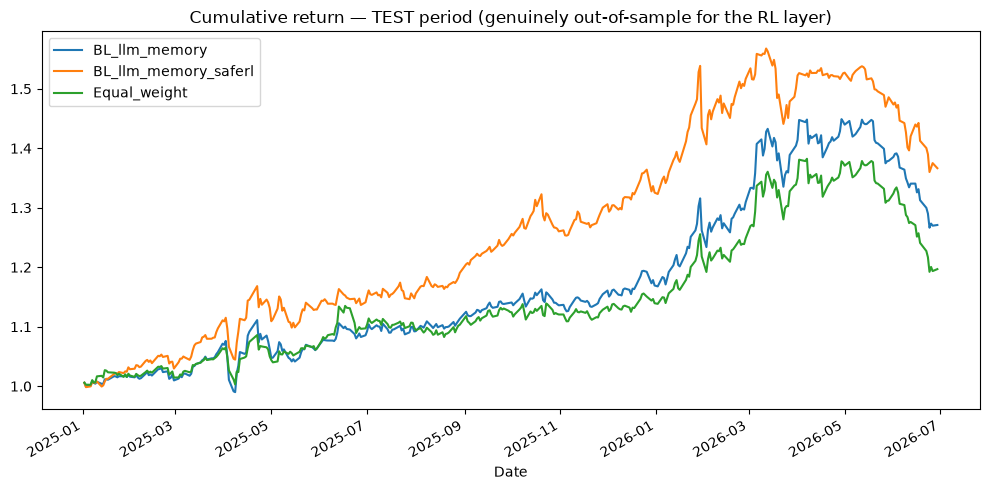

In [11]:
published = pd.DataFrame({
    "BL_baseline": {"ann_return": 0.1278, "ann_vol": 0.1300, "sharpe": 0.9831, "max_drawdown": -0.1326},
    "BL_worldmodel": {"ann_return": 0.1426, "ann_vol": 0.1392, "sharpe": 1.0242, "max_drawdown": -0.1355},
    "Equal_weight": {"ann_return": 0.1291, "ann_vol": 0.1342, "sharpe": 0.9615, "max_drawdown": -0.1375},
})

final_table = pd.concat([published, m_llm.to_frame(), m_saferl.to_frame()], axis=1).round(4)
violation_row = pd.Series({
    "BL_baseline": np.nan, "BL_worldmodel": np.nan, "Equal_weight": np.nan,
    "BL_llm_memory": f"{v_llm['cvar_violations']}/{v_llm['n_days']} cvar, {v_llm['dd_violations']}/{v_llm['n_days']} dd",
    "BL_llm_memory_saferl": f"{v_saferl['cvar_violations']}/{v_saferl['n_days']} cvar, {v_saferl['dd_violations']}/{v_saferl['n_days']} dd",
}, name="violations")

print(final_table)
print()
print(violation_row)

import matplotlib.pyplot as plt

ew_rets = test_rets @ w_eq
plot_df = pd.DataFrame({
    "BL_llm_memory": bt_llm,
    "BL_llm_memory_saferl": bt_saferl,
    "Equal_weight": ew_rets,
})
(1 + plot_df).cumprod().plot(figsize=(10, 5), title="Cumulative return — TEST period (genuinely out-of-sample for the RL layer)")
plt.tight_layout()
plt.show()


## Reading the result

Compare `BL_llm_memory_saferl` against `BL_llm_memory` above on Sharpe, max drawdown, and the
CVaR/drawdown violation counts. Unlike every earlier version of this notebook, there is no
remaining in-sample caveat to restate here: `ppo_lagrangian_trained.zip` was trained end-to-end on
TRAIN (2018-2024) and has not seen a single TEST-period price or a single `bl_llm_memory_weights.csv`
value until this cell. Whatever pattern shows up above — reward and safety improving together,
one improving at the other's expense, or the RL layer adding little on this particular window — is
a genuine out-of-sample finding about how well the policy generalizes from TRAIN's real 2018-2024
risk dynamics (including the 2020 COVID crash and the WTI negative-price event) to TEST's 2025-2026
window, not an artifact of training and evaluating on the same data.


## Save

This completes the guide's 7-step online RL stage (Steps 1-4 in `Step6B_PlainPPO_SanityCheck.ipynb`,
Step 5 in `Step6B_LagrangianSafetyLoop.ipynb`, Step 6 in `Step6B_PackagePolicy.ipynb`, Step 7 here),
on top of the fully-completed offline Decision-Transformer stage (Part A), all retrained on TRAIN.
The out-of-sample gap flagged throughout the original build of this stage is now closed: this
notebook is that out-of-sample check.


In [12]:
pd.DataFrame(saferl_weight_log).set_index("Date").to_csv("bl_llm_memory_saferl_weights.csv")
pd.DataFrame(rl_applied_log).to_csv("saferl_rl_applied_log.csv", index=False)
final_table.to_csv("step7_final_comparison_table.csv")
plot_df.to_csv("step7_daily_returns.csv")

print("Saved bl_llm_memory_saferl_weights.csv")
print("Saved saferl_rl_applied_log.csv")
print("Saved step7_final_comparison_table.csv")
print("Saved step7_daily_returns.csv")

print(f"\nBL_llm_memory        -> Sharpe {m_llm['sharpe']:.4f}, max_dd {m_llm['max_drawdown']:.4f}, "
      f"{v_llm['cvar_violations']}/{v_llm['n_days']} CVaR violations, {v_llm['dd_violations']}/{v_llm['n_days']} drawdown violations")
print(f"BL_llm_memory_saferl  -> Sharpe {m_saferl['sharpe']:.4f}, max_dd {m_saferl['max_drawdown']:.4f}, "
      f"{v_saferl['cvar_violations']}/{v_saferl['n_days']} CVaR violations, {v_saferl['dd_violations']}/{v_saferl['n_days']} drawdown violations")
print("\nOnline RL stage (Steps 1-7) complete, genuinely out-of-sample: trained on TRAIN, evaluated "
      "here on TEST for the first time.")


Saved bl_llm_memory_saferl_weights.csv
Saved saferl_rl_applied_log.csv
Saved step7_final_comparison_table.csv
Saved step7_daily_returns.csv

BL_llm_memory        -> Sharpe 1.1901, max_dd -0.1260, 99/312 CVaR violations, 0/312 drawdown violations
BL_llm_memory_saferl  -> Sharpe 1.5125, max_dd -0.1325, 146/312 CVaR violations, 0/312 drawdown violations

Online RL stage (Steps 1-7) complete, genuinely out-of-sample: trained on TRAIN, evaluated here on TEST for the first time.
